Missing values:
 Material          0
Length_mm         0
Width_mm          0
Height_mm         0
Feature_Count     0
Cycle_Time_min    0
Volume_mm3        0
Quoted_Cost       0
dtype: int64

Data types:
 Material           object
Length_mm         float64
Width_mm          float64
Height_mm         float64
Feature_Count       int32
Cycle_Time_min    float64
Volume_mm3        float64
Quoted_Cost       float64
dtype: object

Sample Data:
    Material   Length_mm    Width_mm  Height_mm  Feature_Count  Cycle_Time_min  \
0  Titanium   15.971545   19.819527  71.325363              3       25.921735   
1   Plastic  130.917978  110.957380  55.929155              1      104.105346   
2  Aluminum   69.727636  112.720673  34.405124              6      113.803278   
3  Titanium  106.628431  131.111681  82.310527              2       47.930571   
4  Titanium  182.437630  147.957353  70.049461              8       36.135637   

     Volume_mm3    Quoted_Cost  
0  2.257793e+04    1815.227567  
1  8.1

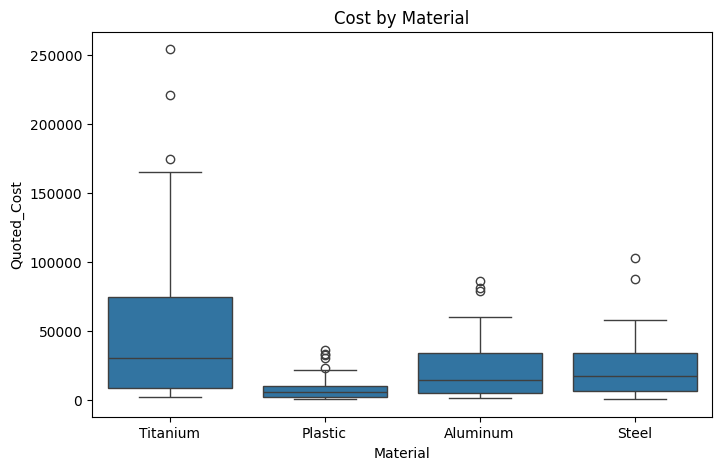

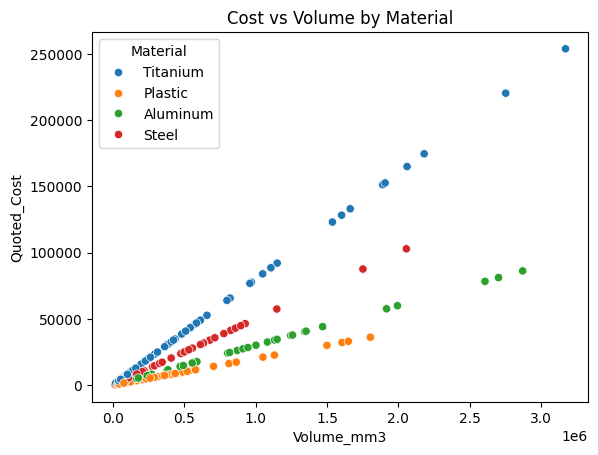

ValueError: could not convert string to float: 'Titanium'

In [2]:
# CNC_Cost_Estimation.ipynb

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Simulate dataset
np.random.seed(42)
materials = ['Aluminum', 'Steel', 'Titanium', 'Plastic']
data = pd.DataFrame({
    'Material': np.random.choice(materials, 200),
    'Length_mm': np.random.uniform(10, 200, 200),
    'Width_mm': np.random.uniform(10, 200, 200),
    'Height_mm': np.random.uniform(5, 100, 200),
    'Feature_Count': np.random.randint(1, 10, 200),
    'Cycle_Time_min': np.random.uniform(5, 120, 200)
})

# Estimate Cost (fake rule: volume * factor + material effect + feature effect)
volume = data['Length_mm'] * data['Width_mm'] * data['Height_mm']
material_factor = {'Aluminum': 0.03, 'Steel': 0.05, 'Titanium': 0.08, 'Plastic': 0.02}
data['Volume_mm3'] = volume
data['Quoted_Cost'] = (
    volume * data['Material'].map(material_factor) +
    data['Feature_Count'] * 5 +
    np.random.normal(0, 20, size=200)
)

# Clean + Explore
print("Missing values:\n", data.isnull().sum())
print("\nData types:\n", data.dtypes)
print("\nSample Data:\n", data.head())

# Feature Engineering
data['Cost_per_mm3'] = data['Quoted_Cost'] / data['Volume_mm3']
data['Feature_Density'] = data['Feature_Count'] / data['Volume_mm3']

# Encode categorical data
data['Material_Code'] = LabelEncoder().fit_transform(data['Material'])

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(x='Material', y='Quoted_Cost', data=data)
plt.title('Cost by Material')
plt.show()

sns.scatterplot(x='Volume_mm3', y='Quoted_Cost', hue='Material', data=data)
plt.title('Cost vs Volume by Material')
plt.show()

sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Model Training
features = ['Volume_mm3', 'Feature_Count', 'Cycle_Time_min', 'Material_Code', 'Feature_Density']
X = data[features]
y = data['Quoted_Cost']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Predicted vs Actual Plot
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Predicted vs Actual Cost")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.show()

# feature importance
feat_importance = pd.Series(model.feature_importances_, index=features)
feat_importance.sort_values().plot(kind='barh')
plt.title("Feature Importances")
plt.show()
